# Eksperiment 2-11 — Razlika formi (EMA 33%)

Predikcija ishoda (Away Win / Draw / Home Win) koristeci SAMO razliku formi (home - away) racunatu kao Exponential Moving Average sa alpha=33% (`form_diff_ema33`).

In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from experiment_utils import save_result_v1, run_one_experiment, run, MLPClassifier

## Priprema podataka

Uzimamo samo `form_diff_ema33` kao feature, target je `result` (-1/0/1) mapiran u klase 0/1/2 (Away/Draw/Home), isti redosled kao `class_names` iznad.

In [ ]:
FEATURE_COLS = ["form_diff_ema33"]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")
data = data.dropna(subset=FEATURE_COLS + ["result"])

X = data[FEATURE_COLS].values.astype(np.float32)
y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))

Train size: 888 Test size: 222


In [3]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0088 | val loss = 0.9108 | val acc = 0.5843
Epoch 100/1000 | train loss = 1.0046 | val loss = 0.9169 | val acc = 0.5843
Epoch 150/1000 | train loss = 1.0079 | val loss = 0.9230 | val acc = 0.5787
Epoch 200/1000 | train loss = 1.0051 | val loss = 0.9167 | val acc = 0.5955
Epoch 250/1000 | train loss = 1.0048 | val loss = 0.9164 | val acc = 0.5843
Epoch 300/1000 | train loss = 1.0046 | val loss = 0.9147 | val acc = 0.5843
Epoch 350/1000 | train loss = 1.0105 | val loss = 0.9166 | val acc = 0.5843
Epoch 400/1000 | train loss = 1.0018 | val loss = 0.9188 | val acc = 0.5843
Epoch 450/1000 | train loss = 0.9999 | val loss = 0.9139 | val acc = 0.5843
Epoch 500/1000 | train loss = 1.0021 | val loss = 0.9139 | val acc = 0.5843
Epoch 550/1000 | train loss = 1.0131 | val loss = 0.9200 | val acc = 0.5843
Epoch 600/1000 | train loss = 1.0082 | val loss = 0.9228 | val acc = 0.5843
Epoch 650/1000 | train loss = 1.0016 | val loss = 0.9202 | val acc = 0.5843
Epoch 700/100

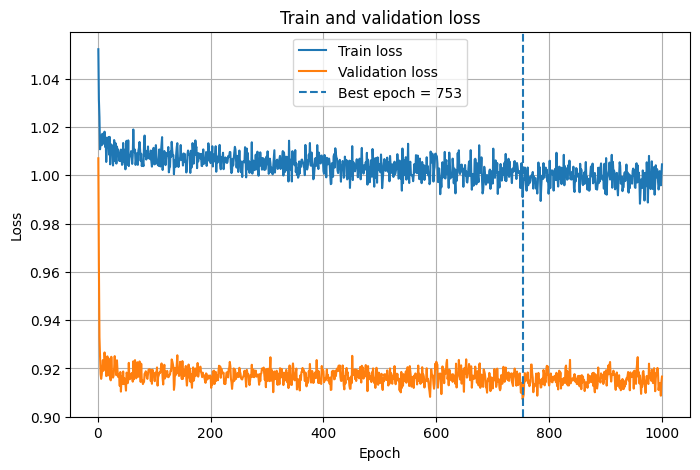

0.5225225225225225

In [4]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

## Trening (10 run-ova)

In [5]:
best_num_epochs = 753

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5225 | Precision: 0.3428 | Recall: 0.4404 | Specificity: 0.7216 | F1: 0.3740

Run 2/10
Accuracy: 0.5180 | Precision: 0.3337 | Recall: 0.4371 | Specificity: 0.7212 | F1: 0.3697

Run 3/10
Accuracy: 0.5180 | Precision: 0.3337 | Recall: 0.4371 | Specificity: 0.7212 | F1: 0.3697

Run 4/10
Accuracy: 0.5225 | Precision: 0.3428 | Recall: 0.4404 | Specificity: 0.7216 | F1: 0.3740

Run 5/10
Accuracy: 0.5225 | Precision: 0.3428 | Recall: 0.4404 | Specificity: 0.7216 | F1: 0.3740

Run 6/10
Accuracy: 0.5225 | Precision: 0.3428 | Recall: 0.4404 | Specificity: 0.7216 | F1: 0.3740

Run 7/10
Accuracy: 0.5225 | Precision: 0.3428 | Recall: 0.4404 | Specificity: 0.7216 | F1: 0.3740

Run 8/10
Accuracy: 0.5180 | Precision: 0.3337 | Recall: 0.4371 | Specificity: 0.7212 | F1: 0.3697

Run 9/10
Accuracy: 0.5225 | Precision: 0.3428 | Recall: 0.4404 | Specificity: 0.7216 | F1: 0.3740

Run 10/10
Accuracy: 0.5225 | Precision: 0.3403 | Recall: 0.4404 | Specificity: 0.7224 | F1: 0.3733

Summary o

## Cuvanje rezultata

In [7]:
save_result_v1(
    experiment_name="Experiment_2-11_EMA33_diff",
    summary=summary
)


Saved result for Experiment_2-11_EMA33_diff
File: ../results/experiment_summary_v1.csv
